In [262]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [263]:
df = pd.read_csv("01-email_classification_svm.csv")
df.head()

,subject_formality_score,sender_relationship_score,email_type
0,-1.496790,0.779258,0
1,-1.217610,0.889601,0
2,-0.375945,-0.823324,1
3,0.639609,-0.362827,1
4,-1.342836,-1.040502,1


In [264]:
df.info()
# 2 tane feature'mız var

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [265]:
df['email_type'].unique()
# Burada sadece 0 ve 1 olarak binary classification var. Spam ya da değil olarak.

array([0, 1])

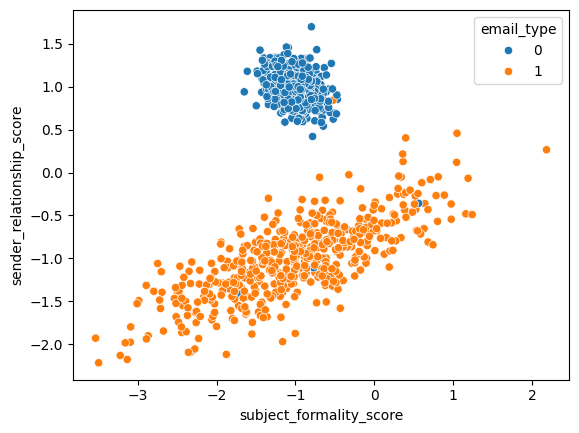

'Normalde olsa lojistik regresyonla cok rahat çözülecek bir problem fakat deep learning öğreticisi \nolması acısından basit probremlerle uğraşıyoruz.'

In [266]:
sns.scatterplot(x=df["subject_formality_score"],y=df["sender_relationship_score"],hue=df["email_type"])
plt.show()
"""Normalde olsa lojistik regresyonla cok rahat çözülecek bir problem fakat deep learning öğreticisi 
olması acısından basit probremlerle uğraşıyoruz."""


In [267]:
X = df[["subject_formality_score","sender_relationship_score"]].values
y = df["email_type"].values

In [268]:
y

array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,

In [269]:
X

array([[-1.49678965,  0.77925822],
       [-1.21760978,  0.88960104],
       [-0.37594518, -0.82332435],
       ...,
       [-1.36975007,  1.0222785 ],
       [-1.1850392 , -1.20266647],
       [-1.17835511,  1.08298346]], shape=(1000, 2))

In [270]:
from sklearn.model_selection import train_test_split
# Manuel bölmek yerine sklearn kütüphanesi ile böleceğiz
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [271]:
len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

In [272]:
type(X_train) # train_test_split fonksiyonu bize bir numpy array'i döndürüyor
# bunu tensore çevirmeliyiz

numpy.ndarray

In [273]:
X_train = torch.tensor(X_train,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test,dtype=torch.float32).unsqueeze(1)
# Dönüşümleri yaptık shape kontrol yapacağız

In [274]:
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)
# burada y'lerde yine dimension uyumsuzluğu olacaktır (800,1) ve (200,1) olarak yapmalıyız.
# yukarıda unsqueeze ile 1 boyut daha ekledik y'lere.

torch.Size([800, 2]) torch.Size([800, 1])
torch.Size([200, 2]) torch.Size([200, 1])


In [275]:
from torch import nn
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Çift katmanlı yapacağız bu yüzden out_feature = 5,
        # tek katman olsa yoksa out_features = 1 olacaktı 
        self.layer_1 = nn.Linear(in_features=2,out_features=5)
        # layer_1'in çıktısıyla layer_2'nin girdisi eşit olmalı
        self.layer_2 = nn.Linear(in_features=5,out_features=1)
    
    def forward(self, x : torch.Tensor) -> torch.Tensor:
        return self.layer_2(self.layer_1(x))

In [276]:
model_0 = ClassificationModel()

In [277]:
# Classification problemlerinde daha çok cross-entropy kullanırız
# 2'li sınıflandırmalarda binary cross-entropy kullanacağız.
loss_fn = nn.BCEWithLogitsLoss() 
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.01)

In [278]:
# torchmetrics kütüphaneside kullanabilir, ilk olarak manuel yazalım
def calculate_accuracy(y_test, y_pred):
    correct = torch.eq(y_test,y_pred).sum().item() 
    # element elemente eşit mi return'i boolean olur. sum() ile doğru sayısını alıp item ile de int değeri alabiliriz.
    accuracy = (correct / len(y_pred)) * 100
    return accuracy

In [279]:
y_logits = model_0(X_test)[:5] # ilk 5 tahmini alalım eğitmeden
y_logits
# bu elde ettiğimiz rakamlar logit'ler

tensor([[-0.1342],
        [-0.2908],
        [-0.1631],
        [-0.2298],
        [-0.1364]], grad_fn=<SliceBackward0>)

In [280]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs
# Bunları sigmoid fonksiyonuna verirsek olasılığa dönüştürmüş oluruz.
# yani ilk 5 datayı örneğin threshhold = 0.5 olarak belirlersek 1 3 5 negatif tarafta 2,4 pozitif tarafta

tensor([[0.4665],
        [0.4278],
        [0.4593],
        [0.4428],
        [0.4660]], grad_fn=<SigmoidBackward0>)

In [281]:
y_preds = torch.round(y_pred_probs) #round fonksiyonunu yuvarlamak için kullanırız
y_preds

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], grad_fn=<RoundBackward0>)

In [282]:
y_test[:5]

tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])

In [283]:
calculate_accuracy(y_test[:5],y_preds)
# %60'lık bir doğruluk çıkmış.

60.0

In [284]:
torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):
    
    model_0.train()

    y_logits = model_0(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits,y_train)
    # loss_fn 'ını BCEWithLogitsLoss() seçtiğimiz için bu şekilde yazıyoruz
    # Eğer BCELoss ile yapsaydık
    # loss = loss_fn(y_pred,y_train) olacaktı teorisinde bu duruma bakmıştık.

    accuracy = calculate_accuracy(y_test=y_train,y_pred=y_pred)

    # Back - propagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits,y_test)
        test_acc = calculate_accuracy(y_test=y_test,y_pred=test_pred)

        if epoch % 5 == 0:
            print(f"Epoch: {epoch}, Train Loss {loss}, Train accuray: {accuracy}, Test Loss: {test_loss}, Test Accuray: {test_acc}")


Epoch: 0, Train Loss 0.723492443561554, Train accuray: 49.75, Test Loss: 0.7176529765129089, Test Accuray: 52.0
Epoch: 5, Train Loss 0.7069980502128601, Train accuray: 49.75, Test Loss: 0.7006773352622986, Test Accuray: 52.0
Epoch: 10, Train Loss 0.6911811232566833, Train accuray: 49.75, Test Loss: 0.6843975186347961, Test Accuray: 52.0
Epoch: 15, Train Loss 0.6759693622589111, Train accuray: 49.75, Test Loss: 0.6687402129173279, Test Accuray: 52.0
Epoch: 20, Train Loss 0.6612993478775024, Train accuray: 49.75, Test Loss: 0.6536413431167603, Test Accuray: 52.0
Epoch: 25, Train Loss 0.6471153497695923, Train accuray: 49.75, Test Loss: 0.6390445232391357, Test Accuray: 52.0
Epoch: 30, Train Loss 0.6333684325218201, Train accuray: 50.125, Test Loss: 0.6249003410339355, Test Accuray: 52.0
Epoch: 35, Train Loss 0.6200160384178162, Train accuray: 52.625, Test Loss: 0.6111659407615662, Test Accuray: 54.0
Epoch: 40, Train Loss 0.6070208549499512, Train accuray: 58.62500000000001, Test Loss: 0.

In [285]:
import numpy as np
def plot_linear_decision_boundary(model, X, y):

    # layer_1: (5,2)
    # layer_2: (1,5)
    # toplam efektif ağırlık = layer_2.weight @ layer_1.weight = (1,2)
    W1 = model.layer_1.weight.detach().numpy()       # shape (5,2)
    b1 = model.layer_1.bias.detach().numpy()         # shape (5,)
    W2 = model.layer_2.weight.detach().numpy()       # shape (1,5)
    b2 = model.layer_2.bias.detach().numpy()[0]      # shape (1,)

    # efektif W ve b
    # W_eff = W2 * W1
    W_eff = W2 @ W1   # shape (1,2)
    w1, w2 = W_eff[0] # iki feature'ın ağırlığı

    # efektif b = W2 * b1 + b2
    b_eff = (W2 @ b1)[0] + b2

    # X aralığı
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # Doğru denkleminden x2 hesaplama
    # w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
    ys = -(w1 * xs + b_eff) / w2

    # Noktalar
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=40)
    plt.plot(xs, ys, "k-", linewidth=3)
    plt.xlabel("subject_formality_score")
    plt.ylabel("sender_relationship_score")
    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

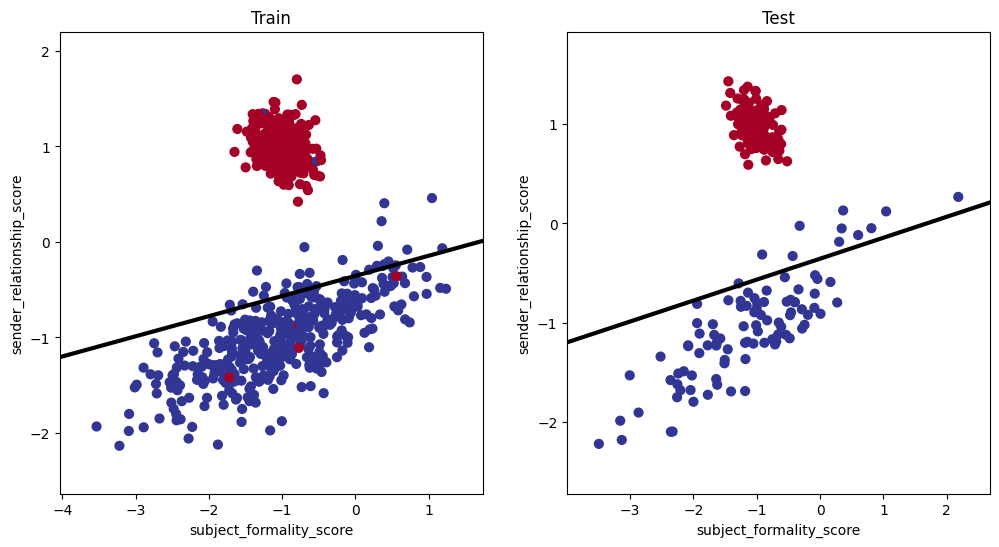

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_linear_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_linear_decision_boundary(model_0, X_test, y_test)
plt.show()
# Decision boundary'lere bakmak için GPT'ye kod yazdırıldı.